<a href="https://colab.research.google.com/github/FRosty799/img_compress_1237050045/blob/main/img_compress_1237050045_Fauzan_Ramdhani_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementasi Algoritma Kompresi Gambar

Kita akan mengimplementasikan tiga algoritma kompresi gambar: Huffman Encoding, K-means Clustering (untuk kuantisasi warna), dan membahas konsep Arithmetic Coding.

### 1. Instalasi Pustaka yang Dibutuhkan

Kita memerlukan `Pillow` (PIL) untuk manipulasi gambar dasar, `numpy` untuk operasi array, dan `scikit-learn` untuk K-means Clustering.

In [2]:
import sys
!{sys.executable} -m pip install Pillow numpy scikit-learn

### 2. Persiapan Gambar Contoh

Kita akan membuat gambar grayscale sederhana sebagai contoh untuk demonstrasi.

### Unggah Gambar Anda Sendiri

Jalankan sel di bawah ini untuk mengunggah gambar dari komputer Anda. Setelah diunggah, gambar ini akan digunakan untuk proses kompresi.

In [ ]:
from google.colab import files
from PIL import Image
import io

# Unggah file gambar
uploaded = files.upload()

# Asumsikan hanya satu file yang diunggah
for filename in uploaded.keys():
    print(f'Nama file yang diunggah: {filename}')
    # Baca gambar dan simpan sebagai objek PIL Image
    uploaded_image = Image.open(io.BytesIO(uploaded[filename]))
    print(f"Gambar berhasil diunggah dengan ukuran: {uploaded_image.size} dan mode: {uploaded_image.mode}")
    break # Hanya ambil file pertama

# Tampilkan gambar yang diunggah
plt.figure(figsize=(5, 5))
plt.imshow(uploaded_image)
plt.title('Gambar yang Diunggah')
plt.axis('off')
plt.show()

Sekarang, kita akan menggunakan `uploaded_image` ini untuk langkah-langkah kompresi berikutnya.

Ukuran gambar dummy: (100, 100)
Mode gambar dummy: L


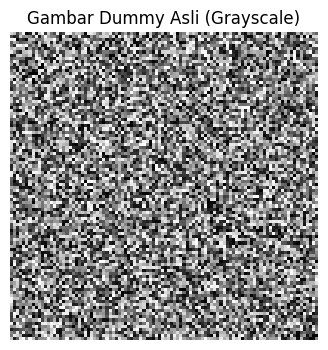

In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Buat gambar grayscale dummy (100x100 piksel)
# Dengan nilai piksel 0-255
width, height = 100, 100
dummy_image_data = np.random.randint(0, 256, (height, width), dtype=np.uint8)
dummy_image = Image.fromarray(dummy_image_data)

print(f"Ukuran gambar dummy: {dummy_image.size}")
print(f"Mode gambar dummy: {dummy_image.mode}")

plt.figure(figsize=(4, 4))
plt.imshow(dummy_image, cmap='gray')
plt.title('Gambar Dummy Asli (Grayscale)')
plt.axis('off')
plt.show()


### 3. Huffman Encoding

Huffman Encoding adalah algoritma kompresi data lossless yang didasarkan pada frekuensi kemunculan simbol. Simbol yang lebih sering muncul akan diberi kode biner yang lebih pendek, sementara simbol yang jarang muncul diberi kode yang lebih panjang.

Dalam konteks gambar, 'simbol' adalah nilai piksel. Kita akan menghitung frekuensi setiap nilai piksel dan membangun pohon Huffman.

In [4]:
import heapq
from collections import defaultdict

# Kelas Node untuk pohon Huffman
class HuffmanNode:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    # Fungsi perbandingan untuk heap (berdasarkan frekuensi)
    def __lt__(self, other):
        return self.freq < other.freq

# Fungsi untuk membangun pohon Huffman
def build_huffman_tree(data):
    # Hitung frekuensi setiap simbol
    frequency = defaultdict(int)
    for char in data:
        frequency[char] += 1

    # Buat leaf nodes dan masukkan ke min-heap
    priority_queue = [HuffmanNode(char, freq) for char, freq in frequency.items()]
    heapq.heapify(priority_queue)

    # Bangun pohon
    while len(priority_queue) > 1:
        left = heapq.heappop(priority_queue)
        right = heapq.heappop(priority_queue)
        # Buat internal node baru
        merged = HuffmanNode(None, left.freq + right.freq)
        merged.left = left
        merged.right = right
        heapq.heappush(priority_queue, merged)

    return priority_queue[0]

# Fungsi untuk menghasilkan kode Huffman dari pohon
def generate_huffman_codes(node, current_code="", codes={}):
    if node is None:
        return

    # Jika ini adalah leaf node, simpan kode
    if node.char is not None:
        codes[node.char] = current_code
        return

    # Rekursif untuk child nodes
    generate_huffman_codes(node.left, current_code + "0", codes)
    generate_huffman_codes(node.right, current_code + "1", codes)
    return codes

# Konversi gambar ke array 1D untuk Huffman
image_array_1d = np.array(dummy_image).flatten()

# Bangun pohon Huffman
huffman_tree_root = build_huffman_tree(image_array_1d)

# Hasilkan kode Huffman
huffman_codes = generate_huffman_codes(huffman_tree_root)

# Cetak beberapa kode (misalnya untuk nilai piksel 0-10)
print("Contoh Kode Huffman untuk beberapa nilai piksel:")
for i in range(11):
    if i in huffman_codes:
        print(f"Nilai piksel {i}: {huffman_codes[i]}")



Contoh Kode Huffman untuk beberapa nilai piksel:
Nilai piksel 0: 10000111
Nilai piksel 1: 11111100
Nilai piksel 2: 00001001
Nilai piksel 3: 10110010
Nilai piksel 4: 10000011
Nilai piksel 5: 01010110
Nilai piksel 6: 01010010
Nilai piksel 7: 111111100
Nilai piksel 8: 11101010
Nilai piksel 9: 00111010
Nilai piksel 10: 11011000


Ukuran data asli (piksel * 8 bit): 80000 bit
Ukuran data terkompresi: 79977 bit
Rasio Kompresi (Compressed / Original): 0.9997


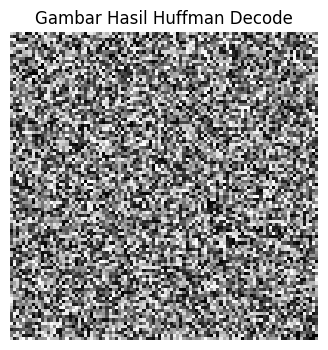

In [5]:
# Fungsi untuk meng-encode data menggunakan kode Huffman
def encode_data(data, codes):
    encoded_string = ""
    for char in data:
        encoded_string += codes[char]
    return encoded_string

# Fungsi untuk men-decode data menggunakan pohon Huffman
def decode_data(encoded_string, huffman_tree_root):
    decoded_data = []
    current_node = huffman_tree_root
    for bit in encoded_string:
        if bit == '0':
            current_node = current_node.left
        else:
            current_node = current_node.right

        if current_node.char is not None:
            decoded_data.append(current_node.char)
            current_node = huffman_tree_root # Reset ke root untuk simbol berikutnya
    return np.array(decoded_data, dtype=np.uint8)

# Encode gambar
encoded_image_data = encode_data(image_array_1d, huffman_codes)

# Decode gambar
decoded_image_array_1d = decode_data(encoded_image_data, huffman_tree_root)
decoded_image = Image.fromarray(decoded_image_array_1d.reshape(dummy_image.size[::-1]))

# Hitung rasio kompresi
original_bits = len(image_array_1d) * 8 # 8 bit per piksel untuk grayscale
compressed_bits = len(encoded_image_data)

print(f"Ukuran data asli (piksel * 8 bit): {original_bits} bit")
print(f"Ukuran data terkompresi: {compressed_bits} bit")
print(f"Rasio Kompresi (Compressed / Original): {compressed_bits / original_bits:.4f}")

# Tampilkan gambar yang telah didecode untuk verifikasi
plt.figure(figsize=(4, 4))
plt.imshow(decoded_image, cmap='gray')
plt.title('Gambar Hasil Huffman Decode')
plt.axis('off')
plt.show()


### 4. K-means Clustering (untuk Kuantisasi Warna)

K-means Clustering dapat digunakan untuk kompresi gambar dengan mengurangi jumlah warna unik dalam gambar, yang dikenal sebagai kuantisasi warna. Setiap piksel kemudian akan diwakili oleh warna "centroid" terdekat dari K cluster yang ditemukan. Ini adalah bentuk kompresi lossy.

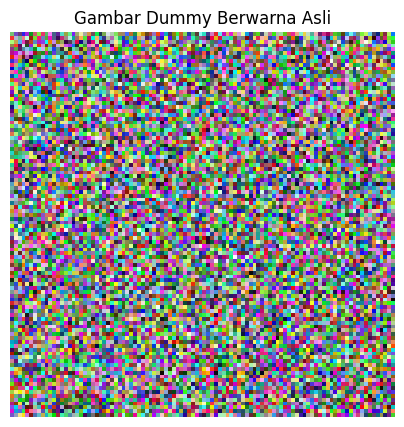

Melakukan K-means Clustering dengan 16 cluster...


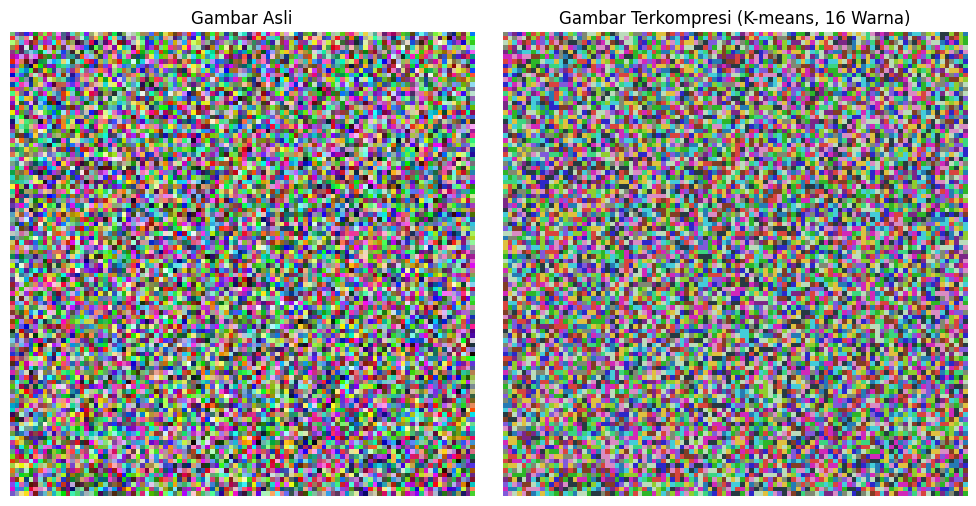

In [7]:
from sklearn.cluster import KMeans

# Untuk demonstrasi K-means, lebih baik menggunakan gambar berwarna.
# Mari kita buat gambar berwarna dummy atau gunakan gambar yang ada jika tersedia.

# Buat gambar berwarna dummy (misalnya 100x100 RGB)
color_width, color_height = 100, 100
color_dummy_image_data = np.random.randint(0, 256, (color_height, color_width, 3), dtype=np.uint8)
color_dummy_image = Image.fromarray(color_dummy_image_data)

plt.figure(figsize=(5, 5))
plt.imshow(color_dummy_image)
plt.title('Gambar Dummy Berwarna Asli')
plt.axis('off')
plt.show()

# Konversi gambar menjadi array 2D dari piksel (height*width, 3)
# di mana 3 adalah kanal warna RGB
pixels = np.array(color_dummy_image).reshape(-1, 3)

# Tentukan jumlah cluster (jumlah warna yang diinginkan setelah kompresi)
k_colors = 16 # Contoh: kurangi menjadi 16 warna

print(f"Melakukan K-means Clustering dengan {k_colors} cluster...")

# Inisialisasi dan jalankan K-means
# n_init='auto' atau nilai integer untuk menangani KMeans versi baru
k_means = KMeans(n_clusters=k_colors, random_state=42, n_init='auto')
k_means.fit(pixels)

# Dapatkan warna-warna centroid (warna yang mewakili setiap cluster)
centroids = k_means.cluster_centers_.astype(np.uint8)

# Ganti setiap piksel dengan warna centroid terdekatnya
compressed_pixels = centroids[k_means.labels_]

# Ubah kembali array piksel terkompresi menjadi bentuk gambar asli
compressed_image_array = compressed_pixels.reshape(color_height, color_width, 3)
compressed_image = Image.fromarray(compressed_image_array)

# Tampilkan gambar asli dan terkompresi
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(color_dummy_image)
axes[0].set_title('Gambar Asli')
axes[0].axis('off')

axes[1].imshow(compressed_image)
axes[1].set_title(f'Gambar Terkompresi (K-means, {k_colors} Warna)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### 5. Arithmetic Coding

Arithmetic Coding adalah metode kompresi data lossless yang lebih canggih daripada Huffman Coding. Alih-alih menetapkan kode biner diskrit ke setiap simbol, Arithmetic Coding mengkodekan seluruh urutan simbol ke dalam satu bilangan pecahan dalam rentang [0, 1).

Kompresi tercapai dengan merepresentasikan string simbol sebagai interval yang semakin sempit dalam rentang ini. Ukuran akhir interval mewakili panjang kode, dan panjang interval berbanding lurus dengan probabilitas gabungan dari urutan simbol. Simbol yang lebih sering akan berkontribusi pada interval yang lebih besar, menghasilkan representasi yang lebih pendek secara keseluruhan.

**Konsep Utama untuk Gambar:**

1.  **Model Probabilitas:** Seperti Huffman, kita perlu model probabilitas untuk nilai piksel (atau kelompok piksel). Ini bisa berupa frekuensi sederhana, atau model yang lebih kompleks (misalnya, probabilitas piksel berdasarkan nilai piksel tetangga).
2.  **Rentang Kode:** Seluruh rentang [0, 1) dibagi sesuai dengan probabilitas kumulatif simbol.
3.  **Encoding Iteratif:** Untuk setiap piksel dalam gambar, rentang saat ini dipersempit berdasarkan probabilitas piksel tersebut. Interval baru menjadi rentang dasar untuk piksel berikutnya.
4.  **Output Akhir:** Setelah semua piksel di-encode, sebuah bilangan tunggal yang terletak di dalam interval akhir dikirim sebagai data terkompresi.
5.  **Decoding:** Decoder menerima bilangan tersebut dan, dengan menggunakan model probabilitas yang sama, secara iteratif mengidentifikasi simbol yang diwakili oleh rentang yang menyempit, hingga semua piksel asli direkonstruksi.

**Mengapa Lebih Kompleks dari Huffman?**

*   **Representasi Pecahan:** Huffman menggunakan integer bit, sementara Arithmetic Coding bekerja dengan pecahan, yang memerlukan aritmetika presisi tinggi atau skalabilitas untuk menghindari underflow.
*   **Model Probabilitas Adaptif:** Meskipun tidak wajib, Arithmetic Coding sering dikombinasikan dengan model probabilitas adaptif (yang berubah seiring data di-encode) untuk efisiensi yang lebih baik, menambah kompleksitas.
*   **Implementasi:** Membangun implementasi Arithmetic Coding yang efisien dan benar dari awal, terutama yang menangani rentang besar data (seperti gambar utuh) dan masalah presisi, adalah tugas yang signifikan. Biasanya, ini diimplementasikan menggunakan pustaka yang sudah ada atau fokus pada demo untuk string yang sangat singkat.

Karena kompleksitasnya, implementasi penuh Arithmetic Coding untuk gambar tidak akan ditunjukkan di sini, tetapi prinsip-prinsip di atas adalah dasar cara kerjanya.